# Layered Calibration Notebook

Works through each calibration layer in order. Each layer section has:
1. **Param cell** - edit these before running the layer
2. **Generate** - writes configs to `configs/calibration/layer_N/`
3. **Run** - batch-runs all configs (parallel); results land in `results/calibration/layer_N/`
4. **Analyze** - loads results, plots metrics, prints a concrete recommendation

Run cells top-to-bottom. Calibrated values are stored in `CAL` and reused by downstream layers.

**Order**: Layer 0 (manual) → 1 → 2 → 3 → 4 → 5 → 6 → 7 → 8

In [1]:
import sys, os, json, gzip, re, shutil
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, as_completed

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Locate project root robustly: look for configs/ from cwd or its parent
_here = Path('.').resolve()
if (_here / 'configs').exists():
    PROJECT_ROOT = _here
elif (_here.parent / 'configs').exists():
    PROJECT_ROOT = _here.parent
else:
    raise RuntimeError(f"Cannot locate project root from {_here}")

sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

from generate_configs import ConfigGenerator, CONFIGS_PATH_PREFIX
from batch_run import run_simulation

plt.rcParams['figure.figsize'] = (13, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Accumulates calibrated values across all layers
CAL = {}
print('Setup complete. PROJECT_ROOT =', PROJECT_ROOT)

Setup complete. PROJECT_ROOT = C:\Users\timon\OneDrive\Dokumente\UNI\Bachelorarbeit\taxi


In [2]:
# Geometry selector
# Set GEOM_VARIANT to 'balanced' (geom 10, base_coords [50,50])
#                  or 'imbalanced' (geom 12, base_coords [15,15])
# Run the whole notebook once per variant.
GEOM_VARIANT = 'balanced'   # <-- change this before running

_GEOM_SETTINGS = {
    'balanced':   {'geom': 10, 'base': 'big_city_base_balanced.conf',   'label': 'balanced'},
    'imbalanced': {'geom': 12, 'base': 'big_city_base_imbalanced.conf', 'label': 'imbalanced'},
}
assert GEOM_VARIANT in _GEOM_SETTINGS, f"GEOM_VARIANT must be one of {list(_GEOM_SETTINGS)}"

GEOM       = _GEOM_SETTINGS[GEOM_VARIANT]['geom']
BASE_CONF  = _GEOM_SETTINGS[GEOM_VARIANT]['base']
print(f'Calibrating for: {GEOM_VARIANT}  (geom={GEOM}, base={BASE_CONF})')

Calibrating for: balanced  (geom=10, base=big_city_base_balanced.conf)


In [27]:
# Shared helpers

def parse_run_id(run_id):
    p = {}
    m = re.search(r'_d_(\d+(?:\.\d+)?)(?:_|$)', run_id)
    if m: p['d'] = float(m.group(1))
    m = re.search(r'_R_(\d+)_(\d+)(?:_|$)', run_id)
    if m: p['R'] = float(f'{m.group(1)}.{m.group(2)}')
    m = re.search(r'_alg_(.+?)_geom_', run_id)
    if m: p['matching'] = m.group(1)
    m = re.search(r'_geom_(\d+)(?:_|$)', run_id)
    if m: p['geom'] = int(m.group(1))
    m = re.search(r'_behav_(\w+?)(?:_ic|_reset|$)', run_id)
    if m: p['behaviour'] = m.group(1)
    return p


def load_aggregates(results_dir):
    """Load final-snapshot rows from all aggregate files in a directory."""
    rows = []
    for f in sorted(Path(results_dir).glob('run_*_aggregates.csv.gz')):
        try:
            df = pd.read_csv(f, index_col=0)
            if df.empty:
                continue
            run_id = re.sub(r'^run_', '', re.sub(r'_aggregates\.csv\.gz$', '', f.name))
            row = df.iloc[-1].to_dict()
            row['run_id'] = run_id
            row.update(parse_run_id(run_id))
            rows.append(row)
        except Exception as e:
            print(f'  Warning: could not load {f.name}: {e}')
    return pd.DataFrame(rows)


def load_all_batches(results_dir, pattern='run_*_aggregates.csv.gz'):
    """Load every batch row (time series) from all aggregate files."""
    all_dfs = []
    for f in sorted(Path(results_dir).glob(pattern)):
        try:
            df = pd.read_csv(f, index_col=0)
            if df.empty:
                continue
            run_id = re.sub(r'^run_', '', re.sub(r'_aggregates\.csv\.gz$', '', f.name))
            df['run_id'] = run_id
            for k, v in parse_run_id(run_id).items():
                df[k] = v
            all_dfs.append(df)
        except Exception as e:
            print(f'  Warning: {f.name}: {e}')
    return pd.concat(all_dfs, ignore_index=True) if all_dfs else pd.DataFrame()


def load_safety_scores(results_dir):
    """Return {run_id: {'initial': [...], 'final': [...]}} from per-taxi metrics."""
    out = {}
    for f in sorted(Path(results_dir).glob('run_*_per_taxi_metrics.json.gz')):
        run_id = re.sub(r'^run_', '', re.sub(r'_per_taxi_metrics\.json\.gz$', '', f.name))
        initial = final = None
        with gzip.open(f, 'rt') as fh:
            for line in fh:
                if line.strip():
                    scores = [float(s) for s in json.loads(line).get('safety_score', []) if s is not None]
                    if scores:
                        if initial is None:
                            initial = scores
                        final = scores
        out[run_id] = {'initial': initial or [], 'final': final or []}
    return out


def load_per_taxi_income(results_dir):
    """Return {run_id: [per-taxi final trip_income]} from per-taxi metrics."""
    out = {}
    for f in sorted(Path(results_dir).glob('run_*_per_taxi_metrics.json.gz')):
        run_id = re.sub(r'^run_', '', re.sub(r'_per_taxi_metrics\.json\.gz$', '', f.name))
        final = None
        with gzip.open(f, 'rt') as fh:
            for line in fh:
                if line.strip():
                    data = json.loads(line)
                    income = data.get('trip_income', [])
                    times = data.get('time_serving', [])
                    if income:
                        final = {'income': income, 'time_serving': times,
                                 'time_to_request': data.get('time_to_request', []),
                                 'time_waiting': data.get('time_waiting', []),
                                 'time_cruising': data.get('time_cruising', [])}
        if final:
            out[run_id] = final
    return out


def load_service_stats(results_dir):
    """Return {run_id: {'n_done', 'n_dropped', 'service_rate'}} by reading ALL batches."""
    stats = {}
    for f in sorted(Path(results_dir).glob('run_*_per_request_metrics.json.gz')):
        run_id = re.sub(r'^run_', '', re.sub(r'_per_request_metrics\.json\.gz$', '', f.name))
        n_done = n_dropped = 0
        with gzip.open(f, 'rt') as fh:
            for line in fh:
                if line.strip():
                    reqs = json.loads(line).get('requests', [])
                    n_done    += sum(1 for r in reqs if r.get('mode') == 'done')
                    n_dropped += sum(1 for r in reqs if r.get('mode') == 'dropped')
        total = n_done + n_dropped
        stats[run_id] = {'n_done': n_done, 'n_dropped': n_dropped,
                         'service_rate': n_done / total if total else None}
    return stats


def run_batch_parallel(config_files, max_workers=None):
    if not config_files:
        print('No configs to run.'); return [], []
    if max_workers is None:
        max_workers = max(1, (os.cpu_count() or 2) - 1)
    total = len(config_files)
    print(f'Running {total} configs with {max_workers} parallel workers...')
    ok, fail = [], []
    with ProcessPoolExecutor(max_workers=max_workers) as ex:
        futs = {ex.submit(run_simulation, str(f)): f for f in config_files}
        for i, fut in enumerate(as_completed(futs)):
            success, path, output, _ = fut.result()
            tag = f'[{i+1}/{total}]'
            if success:
                print(f'  {tag} ok {Path(path).name}')
                ok.append(path)
            else:
                print(f'  {tag} FAIL {Path(path).name}')
                print(f'      {output[:300]}')
                fail.append(path)
    print(f'Done - {len(ok)} OK, {len(fail)} failed')
    return ok, fail


def add_utilization(df):
    active = [c for c in ['avg_time_serving', 'avg_time_waiting',
                          'avg_time_to_request', 'avg_time_cruising'] if c in df.columns]
    if active:
        total = df[active].sum(axis=1)
        df['utilization'] = (df.get('avg_time_serving', 0) / total.where(total > 0)).clip(0, 1)
    return df


def write_configs(configs_and_names, layer_dir):
    Path(layer_dir).mkdir(parents=True, exist_ok=True)
    seen = set()
    written = []
    for fname, content in configs_and_names:
        p = Path(layer_dir) / fname
        if p in seen:
            print(f'  Warning: duplicate config filename skipped: {fname}')
            continue
        seen.add(p)
        p.write_text(content)
        written.append(p)
    print(f'Wrote {len(written)} configs -> {layer_dir}')
    return written


print('Helpers ready')

Helpers ready


---
## Layer 0 - Economy & Geometry *(manual, no simulation)*

Set these in your base config file before running any other layer.  
Quick sanity check formula:

```
trip_profit = price_fixed + avg_trip_length × price_per_dist
            − avg_trip_length × cost_per_unit
            − avg_trip_time  × cost_per_time
```

Result must be clearly positive. Run the cell below to verify.

In [4]:
# Layer 0: sanity check
with open(f'configs/{BASE_CONF}') as f:
    base = json.load(f)

avg_len  = base.get('avg_request_lengths', 50)
velocity = 1
avg_time = avg_len / velocity

revenue = base['price_fixed'] + avg_len * base['price_per_dist']
costs   = avg_len * base['cost_per_unit'] + avg_time * base.get('cost_per_time', 0)
profit  = revenue - costs
margin  = profit / revenue if revenue else 0

print(f'Base config : {BASE_CONF}')
print(f'avg trip    : {avg_len:.1f} units, ~{avg_time:.0f} TU')
print(f'Revenue     : {revenue:.1f}')
print(f'Costs       : {costs:.1f}')
print(f'Profit      : {profit:.1f}  ({margin:.0%} margin)')
if profit > 0:
    print('ok - economics look healthy.')
else:
    print('FAIL - negative profit, adjust price/cost parameters before continuing.')

CAL['base_config'] = BASE_CONF

Base config : big_city_base_balanced.conf
avg trip    : 50.0 units, ~50 TU
Revenue     : 52.0
Costs       : 0.4
Profit      : 51.6  (99% margin)
ok - economics look healthy.


---
## Layer 1 - Supply / Demand Balance

**Goal**: utilization 40–65%, service rate > 90%.  
Runs `nearest` matching with no breaks and constant request rate so measurements reflect true steady-state.

In [5]:
# Layer 1 params - edit these
L1_BASE   = CAL.get('base_config', BASE_CONF)
L1_D      = 258          # characteristic distance; taxi density N = area / d^2
L1_R_LIST = [0.2, 0.3, 0.4, 0.5, 0.6, 0.8]
L1_GEOM   = GEOM
L1_BEHAV  = 1
L1_DAYS   = 0.25
L1_DIR    = f'configs/calibration/layer1_{GEOM_VARIANT}'

In [6]:
# Layer 1: generate configs
gen1 = ConfigGenerator(L1_BASE, days=L1_DAYS)
configs1 = []
for R in L1_R_LIST:
    conf = gen1.generate_config(L1_D, R, 'nearest', L1_GEOM, L1_BEHAV,
                                no_breaks=True, constant_rate=True)
    if conf is not None:
        fname, content = gen1.dump_config(conf)
        configs1.append((fname, content))

written1 = write_configs(configs1, L1_DIR)
print('Configs:', [p.name for p in written1])

Wrote 6 configs -> configs/calibration/layer1_balanced
Configs: ['big_city_base_balanced_days_0_25_d_258_R_0_20_alg_nearest_geom_10_behav_stay_ic_base_reset_false.conf', 'big_city_base_balanced_days_0_25_d_258_R_0_30_alg_nearest_geom_10_behav_stay_ic_base_reset_false.conf', 'big_city_base_balanced_days_0_25_d_258_R_0_40_alg_nearest_geom_10_behav_stay_ic_base_reset_false.conf', 'big_city_base_balanced_days_0_25_d_258_R_0_50_alg_nearest_geom_10_behav_stay_ic_base_reset_false.conf', 'big_city_base_balanced_days_0_25_d_258_R_0_60_alg_nearest_geom_10_behav_stay_ic_base_reset_false.conf', 'big_city_base_balanced_days_0_25_d_258_R_0_80_alg_nearest_geom_10_behav_stay_ic_base_reset_false.conf']


In [7]:
# Layer 1: run
ok1, fail1 = run_batch_parallel(written1)

Running 6 configs with 13 parallel workers...
  [1/6] ok big_city_base_balanced_days_0_25_d_258_R_0_20_alg_nearest_geom_10_behav_stay_ic_base_reset_false.conf
  [2/6] ok big_city_base_balanced_days_0_25_d_258_R_0_30_alg_nearest_geom_10_behav_stay_ic_base_reset_false.conf
  [3/6] ok big_city_base_balanced_days_0_25_d_258_R_0_40_alg_nearest_geom_10_behav_stay_ic_base_reset_false.conf
  [4/6] ok big_city_base_balanced_days_0_25_d_258_R_0_50_alg_nearest_geom_10_behav_stay_ic_base_reset_false.conf
  [5/6] ok big_city_base_balanced_days_0_25_d_258_R_0_60_alg_nearest_geom_10_behav_stay_ic_base_reset_false.conf
  [6/6] ok big_city_base_balanced_days_0_25_d_258_R_0_80_alg_nearest_geom_10_behav_stay_ic_base_reset_false.conf
Done - 6 OK, 0 failed


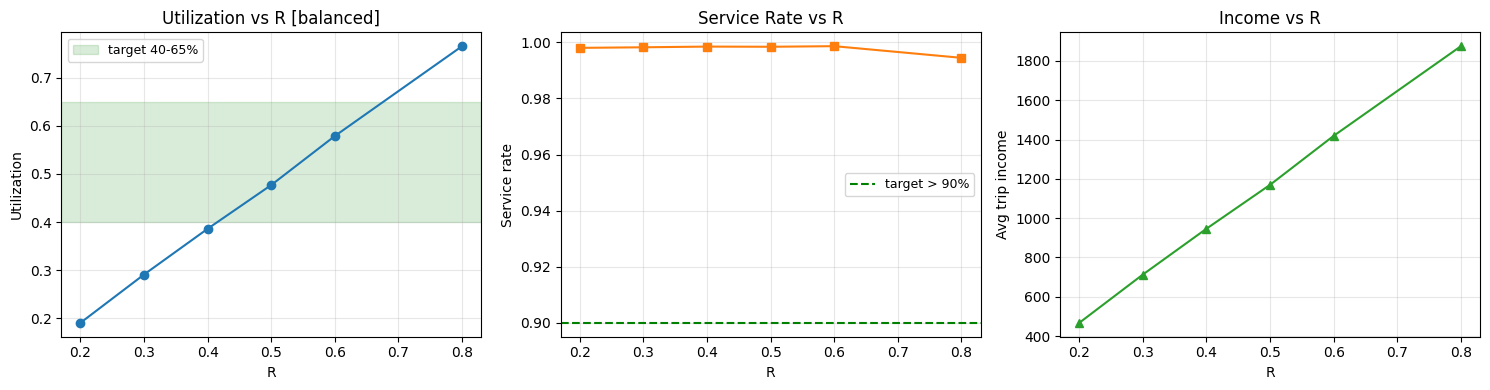

,R,d,utilization,service_rate,avg_trip_income
0,0.2,258.0,0.191,0.998,467.006
1,0.3,258.0,0.291,0.998,712.824
2,0.4,258.0,0.386,0.999,946.146
3,0.5,258.0,0.477,0.998,1169.569
4,0.6,258.0,0.579,0.999,1418.835
5,0.8,258.0,0.766,0.994,1875.078



Layer 1 Recommendation
  ok  R = 0.5
    Utilization : 47.7%
    Service rate: 99.8%
  ok  d = 258

  CAL["R"] = 0.5, CAL["d"] = 258


In [10]:
# Layer 1: analyze
RESULTS_L1 = Path(f'results/calibration/layer1_{GEOM_VARIANT}')

df1 = load_aggregates(RESULTS_L1)
if df1.empty:
    print('No results found - run the simulation cells first.')
else:
    df1 = add_utilization(df1)

    svc1 = load_service_stats(RESULTS_L1)
    df1['service_rate'] = df1['run_id'].map({k: v['service_rate'] for k, v in svc1.items()})

    df1_sorted = df1.sort_values('R') if 'R' in df1.columns else df1

    # Plots
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(df1_sorted['R'], df1_sorted['utilization'], 'o-', color='tab:blue')
    axes[0].axhspan(0.40, 0.65, alpha=0.15, color='green', label='target 40-65%')
    axes[0].set_xlabel('R'); axes[0].set_ylabel('Utilization'); axes[0].set_title(f'Utilization vs R [{GEOM_VARIANT}]')
    axes[0].legend(fontsize=9)

    if 'service_rate' in df1_sorted.columns:
        axes[1].plot(df1_sorted['R'], df1_sorted['service_rate'], 's-', color='tab:orange')
        axes[1].axhline(0.90, color='green', linestyle='--', label='target > 90%')
        axes[1].set_xlabel('R'); axes[1].set_ylabel('Service rate'); axes[1].set_title('Service Rate vs R')
        axes[1].legend(fontsize=9)

    if 'avg_trip_income' in df1_sorted.columns:
        axes[2].plot(df1_sorted['R'], df1_sorted['avg_trip_income'], '^-', color='tab:green')
        axes[2].set_xlabel('R'); axes[2].set_ylabel('Avg trip income'); axes[2].set_title('Income vs R')

    plt.tight_layout()
    plt.show()

    # Summary
    show_cols = [c for c in ['R', 'd', 'utilization', 'service_rate', 'avg_trip_income'] if c in df1.columns]
    display(df1_sorted[show_cols].reset_index(drop=True).round(3))

    # Recommendation
    print('\nLayer 1 Recommendation')
    good = df1[(df1['utilization'] >= 0.40) & (df1['utilization'] <= 0.65)]
    if 'service_rate' in df1.columns:
        good = good[good['service_rate'] >= 0.90]

    if not good.empty:
        good = good.copy()
        good['_score'] = (good['utilization'] - 0.525).abs()
        best = good.loc[good['_score'].idxmin()]
        rec_R = best['R']
        print(f'  ok  R = {rec_R}')
        print(f'    Utilization : {best["utilization"]:.1%}')
        if 'service_rate' in best:
            print(f'    Service rate: {best["service_rate"]:.1%}')
    else:
        df1['_dist'] = (df1['utilization'] - 0.525).abs()
        best = df1.loc[df1['_dist'].idxmin()]
        rec_R = best['R']
        print(f'  no R meets both criteria.')
        print(f'    Closest: R = {rec_R}, utilization = {best["utilization"]:.1%}')
        if best['utilization'] > 0.65:
            print(f'    -> try lower R values')
        elif best['utilization'] < 0.40:
            print(f'    -> try higher R values')
        if 'service_rate' in best and best['service_rate'] < 0.90:
            print(f'    -> service rate low ({best["service_rate"]:.1%}): raise hard_limit or lower R')

    print(f'  ok  d = {L1_D}')
    CAL['R'] = rec_R
    CAL['d'] = L1_D
    print(f'\n  CAL["R"] = {rec_R}, CAL["d"] = {L1_D}')

---
## Layer 2 - Income Baseline

**Uses Layer 1 results** at the chosen R. No new runs needed.  
Measures income per work-time unit to set `income_target_rate`.

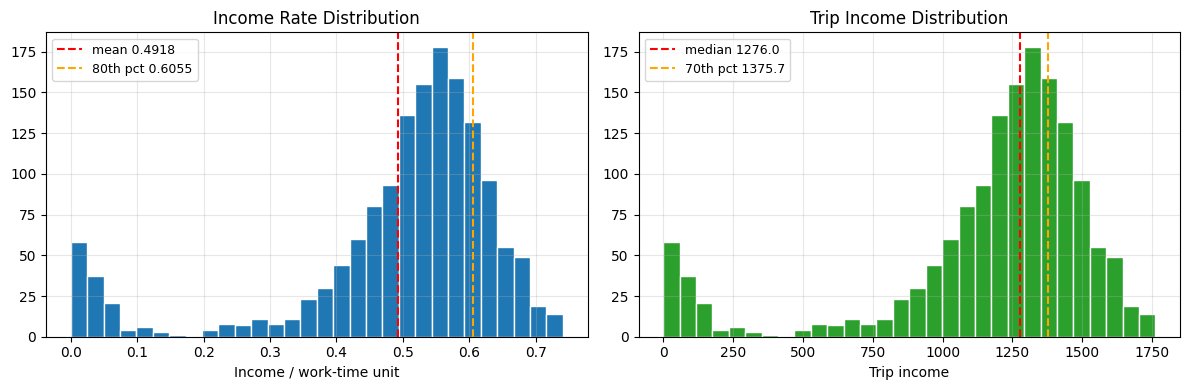

Layer 2 Recommendation
  Mean income rate          : 0.4918 / TU
  income_target_rate        : 0.4181  (85% of mean)
  80% of mean               : 0.3935  (stricter)
  satisfaction_income_ref   : 1375.7  (70th pct trip income)

  Add to base config:
    "income_target_rate": 0.418054
    "satisfaction_income_ref": 1375.7

  CAL["income_target_rate"] = 0.418054


In [11]:
# Layer 2: income baseline from Layer 1 data
RESULTS_L1 = Path(f'results/calibration/layer1_{GEOM_VARIANT}')

ptm1 = load_per_taxi_income(RESULTS_L1)
if not ptm1:
    print('No per-taxi metrics found. Run Layer 1 first.')
else:
    chosen_R = CAL.get('R')
    target_runs = {k: v for k, v in ptm1.items() if f'_R_{str(chosen_R).replace(".", "_")}' in k
                   or (chosen_R is None)}
    if not target_runs:
        target_runs = ptm1
        print(f'  Note: using all Layer 1 runs (could not filter by R={chosen_R})')

    all_income_rates = []
    all_trip_incomes = []
    for run_id, data in target_runs.items():
        incomes  = [float(x) for x in data['income'] if x is not None]
        t_serve  = [float(x) for x in data['time_serving'] if x is not None]
        t_req    = [float(x) for x in data.get('time_to_request', [0]*len(incomes)) if x is not None]
        t_wait   = [float(x) for x in data.get('time_waiting', [0]*len(incomes)) if x is not None]
        t_cruise = [float(x) for x in data.get('time_cruising', [0]*len(incomes)) if x is not None]
        for i in range(min(len(incomes), len(t_serve))):
            work_time = t_serve[i] + (t_req[i] if i < len(t_req) else 0) + \
                        (t_wait[i] if i < len(t_wait) else 0) + (t_cruise[i] if i < len(t_cruise) else 0)
            if work_time > 1:
                all_income_rates.append(incomes[i] / work_time)
        all_trip_incomes.extend(incomes)

    if not all_income_rates:
        print('Could not compute income rates - check per-taxi metrics.')
    else:
        mean_rate = float(np.mean(all_income_rates))
        p80_rate  = float(np.percentile(all_income_rates, 80))
        median_income = float(np.median(all_trip_incomes)) if all_trip_incomes else None
        p70_income    = float(np.percentile(all_trip_incomes, 70)) if all_trip_incomes else None

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].hist(all_income_rates, bins=30, color='tab:blue', edgecolor='white')
        axes[0].axvline(mean_rate, color='red', linestyle='--', label=f'mean {mean_rate:.4f}')
        axes[0].axvline(p80_rate, color='orange', linestyle='--', label=f'80th pct {p80_rate:.4f}')
        axes[0].set_xlabel('Income / work-time unit'); axes[0].set_title('Income Rate Distribution')
        axes[0].legend(fontsize=9)

        if all_trip_incomes:
            axes[1].hist(all_trip_incomes, bins=30, color='tab:green', edgecolor='white')
            axes[1].axvline(median_income, color='red', linestyle='--', label=f'median {median_income:.1f}')
            axes[1].axvline(p70_income, color='orange', linestyle='--', label=f'70th pct {p70_income:.1f}')
            axes[1].set_xlabel('Trip income'); axes[1].set_title('Trip Income Distribution')
            axes[1].legend(fontsize=9)

        plt.tight_layout(); plt.show()

        rec_itr  = round(mean_rate * 0.85, 6)
        rec_iref = round(p70_income, 1) if p70_income else None

        print('Layer 2 Recommendation')
        print(f'  Mean income rate          : {mean_rate:.4f} / TU')
        print(f'  income_target_rate        : {rec_itr:.4f}  (85% of mean)')
        print(f'  80% of mean               : {mean_rate * 0.80:.4f}  (stricter)')
        if rec_iref:
            print(f'  satisfaction_income_ref   : {rec_iref:.1f}  (70th pct trip income)')
        print()
        print('  Add to base config:')
        print(f'    "income_target_rate": {rec_itr:.6f}')
        if rec_iref:
            print(f'    "satisfaction_income_ref": {rec_iref:.1f}')

        CAL['income_target_rate']    = rec_itr
        CAL['mean_income_rate']      = mean_rate
        CAL['satisfaction_income_ref'] = rec_iref
        CAL['median_trip_income']    = median_income
        print(f'\n  CAL["income_target_rate"] = {rec_itr}')

---
## Layer 3 - Safety Score Dynamics

**Goal**: safety score drops 20–40 points over a long shift; meaningful recovery during breaks.  
Step 1 sweeps `safety_score_change_serving_rate` to find the right degradation speed.  
Step 2 (with breaks) checks break recovery.

In [12]:
# Layer 3 params - edit these
L3_BASE          = CAL.get('base_config', BASE_CONF)
L3_D             = CAL.get('d', 258)
L3_R             = CAL.get('R', 0.5)
L3_GEOM          = GEOM
L3_BEHAV         = 1
L3_DAYS          = 0.25   # ~long-shift duration (2200 TU with big_city_base)
L3_DIR           = f'configs/calibration/layer3_{GEOM_VARIANT}'

# Negative values: degradation per TU while serving
L3_SERVING_RATES = [-0.005, -0.010, -0.015, -0.020, -0.025, -0.030]

L3_RECOVERY_C    = 180.0  # recovery constant C for R(t) = t / (t + C)

In [13]:
# Layer 3: generate configs (sweep serving rate)
gen3 = ConfigGenerator(L3_BASE, days=L3_DAYS)
configs3 = []
for rate in L3_SERVING_RATES:
    conf = gen3.generate_config(L3_D, L3_R, 'nearest', L3_GEOM, L3_BEHAV,
                                no_breaks=True, constant_rate=True)
    if conf is None:
        continue
    conf['safety_score_change_serving_rate'] = rate
    conf['safety_score_break_recovery_constant'] = L3_RECOVERY_C
    rate_tag = str(abs(rate)).replace('.', 'p')
    fname, content = gen3.dump_config(conf)
    fname = fname.replace('.conf', f'_srate_{rate_tag}.conf')
    conf_dict = json.loads(content)
    conf_dict['safety_score_change_serving_rate'] = rate
    conf_dict['_srate_tag'] = rate
    content = json.dumps(conf_dict, indent=4) + '\n'
    configs3.append((fname, content))

written3 = write_configs(configs3, L3_DIR)
print('Configs:', [p.name for p in written3])

Wrote 6 configs -> configs/calibration/layer3_balanced
Configs: ['big_city_base_balanced_days_0_25_d_258_R_0_50_alg_nearest_geom_10_behav_stay_ic_base_reset_false_srate_0p005.conf', 'big_city_base_balanced_days_0_25_d_258_R_0_50_alg_nearest_geom_10_behav_stay_ic_base_reset_false_srate_0p01.conf', 'big_city_base_balanced_days_0_25_d_258_R_0_50_alg_nearest_geom_10_behav_stay_ic_base_reset_false_srate_0p015.conf', 'big_city_base_balanced_days_0_25_d_258_R_0_50_alg_nearest_geom_10_behav_stay_ic_base_reset_false_srate_0p02.conf', 'big_city_base_balanced_days_0_25_d_258_R_0_50_alg_nearest_geom_10_behav_stay_ic_base_reset_false_srate_0p025.conf', 'big_city_base_balanced_days_0_25_d_258_R_0_50_alg_nearest_geom_10_behav_stay_ic_base_reset_false_srate_0p03.conf']


In [14]:
# Layer 3: run
ok3, fail3 = run_batch_parallel(written3)

Running 6 configs with 13 parallel workers...
  [1/6] ok big_city_base_balanced_days_0_25_d_258_R_0_50_alg_nearest_geom_10_behav_stay_ic_base_reset_false_srate_0p01.conf
  [2/6] ok big_city_base_balanced_days_0_25_d_258_R_0_50_alg_nearest_geom_10_behav_stay_ic_base_reset_false_srate_0p02.conf
  [3/6] ok big_city_base_balanced_days_0_25_d_258_R_0_50_alg_nearest_geom_10_behav_stay_ic_base_reset_false_srate_0p005.conf
  [4/6] ok big_city_base_balanced_days_0_25_d_258_R_0_50_alg_nearest_geom_10_behav_stay_ic_base_reset_false_srate_0p03.conf
  [5/6] ok big_city_base_balanced_days_0_25_d_258_R_0_50_alg_nearest_geom_10_behav_stay_ic_base_reset_false_srate_0p015.conf
  [6/6] ok big_city_base_balanced_days_0_25_d_258_R_0_50_alg_nearest_geom_10_behav_stay_ic_base_reset_false_srate_0p025.conf
Done - 6 OK, 0 failed


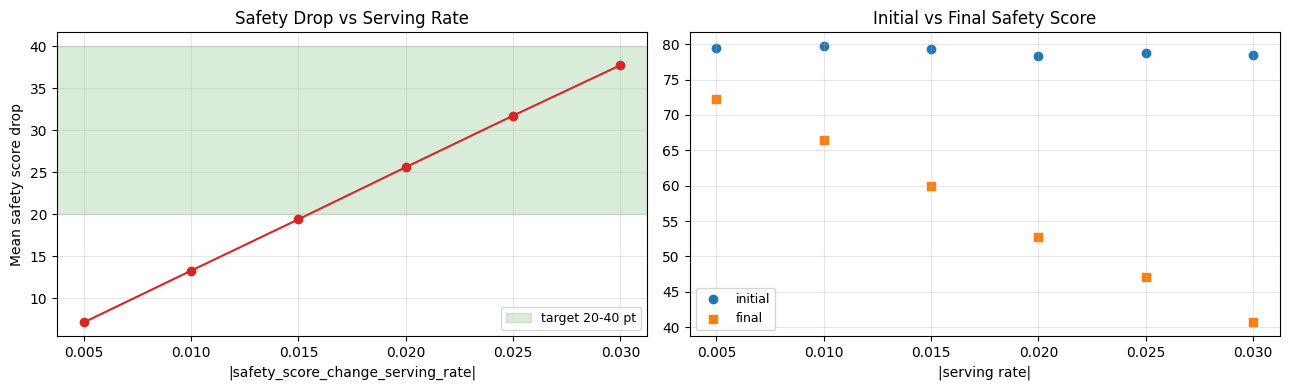

,srate,mean_initial,mean_final,mean_drop
0,-0.030,78.411,40.673,37.738
1,-0.025,78.765,47.031,31.734
2,-0.020,78.331,52.725,25.606
3,-0.015,79.388,59.979,19.409
4,-0.010,79.725,66.423,13.301
5,-0.005,79.447,72.297,7.150



Layer 3 Recommendation
  ok  safety_score_change_serving_rate = -0.025
    Mean drop: 31.7 points

  Recovery constant C = 180.0
  1440-TU rest recovers 89% of the drop
  Expected drop at 60% utilization over long shift: 43.2 pts

  Add to base config:
    "safety_score_change_serving_rate": -0.025
    "safety_score_break_recovery_constant": 180.0

  CAL["safety_score_change_serving_rate"] = -0.025


In [15]:
# Layer 3: analyze
RESULTS_L3 = Path(f'results/calibration/layer3_{GEOM_VARIANT}')

safety3 = load_safety_scores(RESULTS_L3)
if not safety3:
    print('No safety data found - run Layer 3 simulations first.')
else:
    rows3 = []
    for run_id, sc in safety3.items():
        if not sc['initial'] or not sc['final']:
            continue
        mean_drop = np.mean(sc['initial']) - np.mean(sc['final'])
        m = re.search(r'_srate_(\d+p\d+)', run_id)
        srate = -float(m.group(1).replace('p', '.')) if m else None
        rows3.append({'run_id': run_id, 'srate': srate,
                      'mean_initial': np.mean(sc['initial']),
                      'mean_final':   np.mean(sc['final']),
                      'mean_drop':    mean_drop})

    df3 = pd.DataFrame(rows3).sort_values('srate')

    # Plots
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(df3['srate'].abs(), df3['mean_drop'], 'o-', color='tab:red')
    axes[0].axhspan(20, 40, alpha=0.15, color='green', label='target 20-40 pt')
    axes[0].set_xlabel('|safety_score_change_serving_rate|')
    axes[0].set_ylabel('Mean safety score drop')
    axes[0].set_title('Safety Drop vs Serving Rate')
    axes[0].legend(fontsize=9)

    axes[1].scatter(df3['srate'].abs(), df3['mean_initial'], label='initial', marker='o')
    axes[1].scatter(df3['srate'].abs(), df3['mean_final'],   label='final',   marker='s')
    axes[1].set_xlabel('|serving rate|')
    axes[1].set_title('Initial vs Final Safety Score')
    axes[1].legend(fontsize=9)

    plt.tight_layout(); plt.show()
    display(df3[['srate','mean_initial','mean_final','mean_drop']].reset_index(drop=True).round(3))

    # Recommendation
    in_range = df3[(df3['mean_drop'] >= 20) & (df3['mean_drop'] <= 40)]
    print('\nLayer 3 Recommendation')
    if not in_range.empty:
        best3 = in_range.iloc[len(in_range)//2]
        rec_rate = best3['srate']
        print(f'  ok  safety_score_change_serving_rate = {rec_rate}')
        print(f'    Mean drop: {best3["mean_drop"]:.1f} points')
    else:
        target_drop = 30
        df3s = df3.dropna(subset=['srate']).sort_values('srate')
        if len(df3s) >= 2:
            rec_rate = float(np.interp(target_drop, df3s['mean_drop'], df3s['srate']))
            print(f'  ~ interpolated serving_rate ~= {rec_rate:.4f} (targets 30 pt drop)')
        else:
            rec_rate = L3_SERVING_RATES[len(L3_SERVING_RATES)//2]
            print(f'  ? not enough data, defaulting to {rec_rate}')

    long_shift_tu = 2880
    expected_drop = long_shift_tu * 0.60 * abs(rec_rate)
    recovery_1440 = 1440 / (1440 + L3_RECOVERY_C)
    print(f'\n  Recovery constant C = {L3_RECOVERY_C}')
    print(f'  1440-TU rest recovers {recovery_1440:.0%} of the drop')
    print(f'  Expected drop at 60% utilization over long shift: {expected_drop:.1f} pts')
    if recovery_1440 < 0.75:
        print('  -> recovery slow; consider reducing C')
    elif recovery_1440 > 0.95:
        print('  -> recovery very fast; consider increasing C')

    print(f'\n  Add to base config:')
    print(f'    "safety_score_change_serving_rate": {rec_rate}')
    print(f'    "safety_score_break_recovery_constant": {L3_RECOVERY_C}')

    CAL['safety_score_change_serving_rate'] = rec_rate
    CAL['safety_score_break_recovery_constant'] = L3_RECOVERY_C
    print(f'\n  CAL["safety_score_change_serving_rate"] = {rec_rate}')

---
### Layer 3 Step 2 - Break Recovery Validation

**Goal**: confirm `safety_score_break_recovery_constant` by simulation (Step 1 was purely analytical).
Runs 1-day simulations with breaks enabled; sweeps constant C over [60, 120, 180, 240, 360].
**Target**: a typical break event should recover 50-80% of the preceding safety score drop.

In [ ]:
# Layer 3 Step 2 params + generate: sweep recovery constant with breaks enabled
L3B_BASE               = CAL.get('base_config', BASE_CONF)
L3B_D                  = CAL.get('d', 258)
L3B_R                  = CAL.get('R', 0.5)
L3B_GEOM               = GEOM
L3B_BEHAV              = 1
L3B_DAYS               = 1      # full day so multiple break cycles occur
L3B_DIR                = f'configs/calibration/layer3b_{GEOM_VARIANT}'
L3B_RECOVERY_CONSTANTS = [60, 120, 180, 240, 360]
L3B_SERVING_RATE       = CAL.get('safety_score_change_serving_rate', -0.025)

gen3b = ConfigGenerator(L3B_BASE, days=L3B_DAYS)
configs3b = []
for C in L3B_RECOVERY_CONSTANTS:
    conf = gen3b.generate_config(L3B_D, L3B_R, 'nearest', L3B_GEOM, L3B_BEHAV,
                                 no_breaks=False, constant_rate=True)
    if conf is None:
        continue
    conf['safety_score_change_serving_rate'] = L3B_SERVING_RATE
    conf['safety_score_break_recovery_constant'] = float(C)
    fname, content = gen3b.dump_config(conf)
    srate_tag = str(abs(L3B_SERVING_RATE)).replace('.', 'p')
    fname = fname.replace('.conf', f'_srate_{srate_tag}_recov_{C}.conf')
    conf_dict = json.loads(content)
    conf_dict['safety_score_break_recovery_constant'] = float(C)
    conf_dict['_recov_tag'] = C
    configs3b.append((fname, json.dumps(conf_dict, indent=4) + '\n'))

written3b = write_configs(configs3b, L3B_DIR)
print('Configs:', [p.name for p in written3b])

In [ ]:
# Layer 3 Step 2: run
ok3b, fail3b = run_batch_parallel(written3b)

In [ ]:
# Layer 3 Step 2: analyze break recovery
RESULTS_L3B = Path(f'results/calibration/layer3b_{GEOM_VARIANT}')


def load_break_recovery(results_dir):
    """Measure mean safety score recovery during break periods from per-taxi time series."""
    out = {}
    for f in sorted(Path(results_dir).glob('run_*_per_taxi_metrics.json.gz')):
        run_id = re.sub(r'^run_', '', re.sub(r'_per_taxi_metrics\.json\.gz$', '', f.name))
        batches = []
        with gzip.open(f, 'rt') as fh:
            for line in fh:
                if line.strip():
                    batches.append(json.loads(line))
        if len(batches) < 4:
            continue

        n_taxis = len(batches[0].get('safety_score', []))
        recovery_deltas, pre_drop_deltas = [], []

        for taxi_idx in range(n_taxis):
            scores = [b['safety_score'][taxi_idx] for b in batches
                      if taxi_idx < len(b.get('safety_score', []))]
            breaks = [bool(b.get('on_break', [False] * n_taxis)[taxi_idx]) for b in batches
                      if taxi_idx < len(b.get('on_break', []))]
            if len(scores) < len(batches):
                continue
            i = 0
            while i < len(breaks) - 1:
                if not breaks[i] and i + 1 < len(breaks) and breaks[i + 1]:
                    j = i + 1
                    while j < len(breaks) and breaks[j]:
                        j += 1
                    if j < len(scores):
                        recovery = scores[j] - scores[i]
                        pre_drop = scores[max(0, i - 1)] - scores[i]
                        if pre_drop > 0:
                            recovery_deltas.append(recovery)
                            pre_drop_deltas.append(pre_drop)
                    i = j
                else:
                    i += 1

        m = re.search(r'_recov_(\d+)', run_id)
        C = int(m.group(1)) if m else None
        mean_rec  = float(np.mean(recovery_deltas))  if recovery_deltas  else 0.0
        mean_drop = float(np.mean(pre_drop_deltas)) if pre_drop_deltas else 1.0
        out[run_id] = {
            'C': C,
            'break_events': len(recovery_deltas),
            'mean_recovery': mean_rec,
            'mean_pre_drop': mean_drop,
            'recovery_ratio': mean_rec / mean_drop if mean_drop > 0 else 0.0,
        }
    return out


rec3b = load_break_recovery(RESULTS_L3B)
if not rec3b:
    print('No results - run Layer 3 Step 2 first.')
else:
    rows3b = sorted([v for v in rec3b.values() if v['C'] is not None], key=lambda x: x['C'])
    df3b = pd.DataFrame(rows3b)
    display(df3b[['C', 'break_events', 'mean_recovery', 'mean_pre_drop', 'recovery_ratio']].round(3))

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(df3b['C'], df3b['recovery_ratio'], 'o-', color='tab:green')
    ax.axhspan(0.50, 0.80, alpha=0.15, color='green', label='target 50-80% recovery ratio')
    ax.set_xlabel('safety_score_break_recovery_constant C')
    ax.set_ylabel('Recovery ratio per break event')
    ax.set_title('Break Recovery vs Constant C')
    ax.legend(fontsize=9)
    plt.tight_layout(); plt.show()

    in_range3b = df3b[(df3b['recovery_ratio'] >= 0.50) & (df3b['recovery_ratio'] <= 0.80)]
    print('\nLayer 3 Step 2 Recommendation')
    if not in_range3b.empty:
        best3b = in_range3b.iloc[len(in_range3b) // 2]
        rec_C = int(best3b['C'])
        print(f'  ok  safety_score_break_recovery_constant = {rec_C}')
        print(f'    Recovery ratio: {best3b["recovery_ratio"]:.1%} per break event')
    elif not df3b.empty:
        df3b_v = df3b.dropna(subset=['C']).copy()
        df3b_v['dist'] = (df3b_v['recovery_ratio'] - 0.65).abs()
        best3b = df3b_v.loc[df3b_v['dist'].idxmin()]
        rec_C = int(best3b['C'])
        print(f'  ~ closest to 65% target: C = {rec_C}  (recovery ratio: {best3b["recovery_ratio"]:.1%})')
    else:
        rec_C = int(CAL.get('safety_score_break_recovery_constant', 180))
        print(f'  ? no break events detected; keeping C = {rec_C}')

    prev_C = int(CAL.get('safety_score_break_recovery_constant', 180))
    if abs(rec_C - prev_C) > 30:
        print(f'\n  ** C updated from {prev_C} (analytical) to {rec_C} (simulation-confirmed)')
        CAL['safety_score_break_recovery_constant'] = rec_C
    else:
        print(f'\n  Analytical C = {prev_C} confirmed by simulation (suggested {rec_C})')
    print(f'  CAL["safety_score_break_recovery_constant"] = {CAL["safety_score_break_recovery_constant"]}')

---
## Layer 4 - Satisfaction Normalization

**Uses Layer 1/2 data** - no new simulation needed.  
Sets `satisfaction_income_ref` and `satisfaction_change_waiting_rate` so income and waiting components are on comparable scales.

In [16]:
# Layer 4: satisfaction normalization
RESULTS_L1 = Path(f'results/calibration/layer1_{GEOM_VARIANT}')

R_chosen  = CAL.get('R', 0.5)
with open(f'configs/{CAL.get("base_config", BASE_CONF)}') as f:
    base_for_l4 = json.load(f)

avg_len_l4 = base_for_l4.get('avg_request_lengths', 50)
velocity_l4 = 1

inter_trip_tu = avg_len_l4 / (velocity_l4 * R_chosen)

income_ref = CAL.get('satisfaction_income_ref') or CAL.get('median_trip_income')

typical_sat_per_trip = 0.3
if inter_trip_tu > 0:
    rec_wait_rate = -(typical_sat_per_trip / inter_trip_tu)
else:
    rec_wait_rate = -0.003

print('Layer 4 Recommendation')
print(f'  Avg request length       : {avg_len_l4} units')
print(f'  Chosen R                 : {R_chosen}')
print(f'  Est. inter-trip interval : {inter_trip_tu:.0f} TU')
print()
if income_ref:
    print(f'  satisfaction_income_ref  : {income_ref:.1f}')
else:
    income_ref = 50
    print(f'  income_ref not set from Layer 2; using fallback = {income_ref}')

print(f'  satisfaction_change_waiting_rate : {rec_wait_rate:.5f} / TU')
print(f'    ({inter_trip_tu:.0f} TU idle costs {abs(rec_wait_rate * inter_trip_tu):.2f} sat = one typical trip)')
print()
print('  Add to base config:')
print(f'    "satisfaction_income_ref": {income_ref:.1f}')
print(f'    "satisfaction_change_waiting_rate": {rec_wait_rate:.5f}')
print(f'    "satisfaction_income_weight": 0.5')

CAL['satisfaction_income_ref'] = income_ref
CAL['satisfaction_change_waiting_rate'] = rec_wait_rate
print(f'\n  CAL["satisfaction_income_ref"] = {income_ref:.1f}')
print(f'  CAL["satisfaction_change_waiting_rate"] = {rec_wait_rate:.5f}')

Layer 4 Recommendation
  Avg request length       : 50 units
  Chosen R                 : 0.5
  Est. inter-trip interval : 100 TU

  satisfaction_income_ref  : 1375.7
  satisfaction_change_waiting_rate : -0.00300 / TU
    (100 TU idle costs 0.30 sat = one typical trip)

  Add to base config:
    "satisfaction_income_ref": 1375.7
    "satisfaction_change_waiting_rate": -0.00300
    "satisfaction_income_weight": 0.5

  CAL["satisfaction_income_ref"] = 1375.7
  CAL["satisfaction_change_waiting_rate"] = -0.00300


---
## Layer 5 - Driver Flexibility

**Goal**: `driver_flexibility_threshold` at the 70th percentile of the income shortfall distribution; sigmoid temperature controls the ramp width.  
Requires `income_target_rate` from Layer 2.

In [28]:
# Layer 5 params - edit these
L5_BASE   = CAL.get('base_config', BASE_CONF)
L5_D      = CAL.get('d', 258)
L5_R      = CAL.get('R', 0.5)      # fixed from Layer 1 - do not change
L5_R_HIGH = 0.7                     # higher R to validate the flexibility mechanism under load
L5_GEOM   = GEOM
L5_BEHAV  = 1
L5_DAYS   = 1
L5_DIR    = f'configs/calibration/layer5_{GEOM_VARIANT}'

# Calibration target: sigmoid sharpness of the flexibility curve.
# Lower T = sharper switch at threshold; higher T = more gradual ramp.
L5_TEMPERATURES = [0.05, 0.10, 0.15, 0.20, 0.30]

# NOTE: At R=0.5 essentially no drivers fall below income_target, so the 70th-percentile
# shortfall is 0 and driver_flexibility_threshold = 0 (correct: no drivers struggle at
# this load level). L5_R_HIGH generates additional runs at higher market load where
# income shortfall actually occurs, validating the temperature calibration under stress.

In [29]:
# Layer 5: generate configs (primary R + stress R for mechanism validation)
gen5 = ConfigGenerator(L5_BASE, days=L5_DAYS)

income_target = CAL.get('income_target_rate')
if income_target is None:
    print('WARNING: income_target_rate not set in CAL - run Layer 2 first.')
    income_target = 0.001

configs5 = []
for R_test in [L5_R, L5_R_HIGH]:
    for T in L5_TEMPERATURES:
        conf = gen5.generate_config(L5_D, R_test, 'nearest_distance_pref', L5_GEOM, L5_BEHAV,
                                    no_breaks=False, constant_rate=False)
        if conf is None:
            continue
        conf['income_target_rate'] = income_target
        conf['driver_flexibility_threshold'] = 0.5   # placeholder; derived from shortfall analysis
        conf['driver_flexibility_temperature'] = T
        fname, content = gen5.dump_config(conf)
        T_tag = str(T).replace('.', 'p')
        fname = fname.replace('.conf', f'_ftemp_{T_tag}.conf')
        conf_dict = json.loads(content)
        conf_dict['_ftemp_tag'] = T
        configs5.append((fname, json.dumps(conf_dict, indent=4) + '\n'))

written5 = write_configs(configs5, L5_DIR)
print('Configs:', [p.name for p in written5])

Wrote 5 configs -> configs/calibration/layer5_balanced
Configs: ['big_city_base_balanced_days_1_d_258_R_0_50_alg_nearest_distance_pref_geom_10_behav_stay_ic_base_reset_false_ftemp_0p05.conf', 'big_city_base_balanced_days_1_d_258_R_0_50_alg_nearest_distance_pref_geom_10_behav_stay_ic_base_reset_false_ftemp_0p1.conf', 'big_city_base_balanced_days_1_d_258_R_0_50_alg_nearest_distance_pref_geom_10_behav_stay_ic_base_reset_false_ftemp_0p15.conf', 'big_city_base_balanced_days_1_d_258_R_0_50_alg_nearest_distance_pref_geom_10_behav_stay_ic_base_reset_false_ftemp_0p2.conf', 'big_city_base_balanced_days_1_d_258_R_0_50_alg_nearest_distance_pref_geom_10_behav_stay_ic_base_reset_false_ftemp_0p3.conf']


In [30]:
# Layer 5: run
ok5, fail5 = run_batch_parallel(written5)

Running 5 configs with 13 parallel workers...
  [1/5] FAIL big_city_base_balanced_days_1_d_258_R_0_50_alg_nearest_distance_pref_geom_10_behav_stay_ic_base_reset_false_ftemp_0p1.conf
      Error running configs\calibration\layer5_balanced\big_city_base_balanced_days_1_d_258_R_0_50_alg_nearest_distance_pref_geom_10_behav_stay_ic_base_reset_false_ftemp_0p1.conf:
Traceback (most recent call last):
  File "C:\Users\timon\OneDrive\Dokumente\UNI\Bachelorarbeit\taxi\run.py", line [
  [2/5] ok big_city_base_balanced_days_1_d_258_R_0_50_alg_nearest_distance_pref_geom_10_behav_stay_ic_base_reset_false_ftemp_0p15.conf
  [3/5] ok big_city_base_balanced_days_1_d_258_R_0_50_alg_nearest_distance_pref_geom_10_behav_stay_ic_base_reset_false_ftemp_0p3.conf
  [4/5] ok big_city_base_balanced_days_1_d_258_R_0_50_alg_nearest_distance_pref_geom_10_behav_stay_ic_base_reset_false_ftemp_0p2.conf
  [5/5] ok big_city_base_balanced_days_1_d_258_R_0_50_alg_nearest_distance_pref_geom_10_behav_stay_ic_base_reset_fals

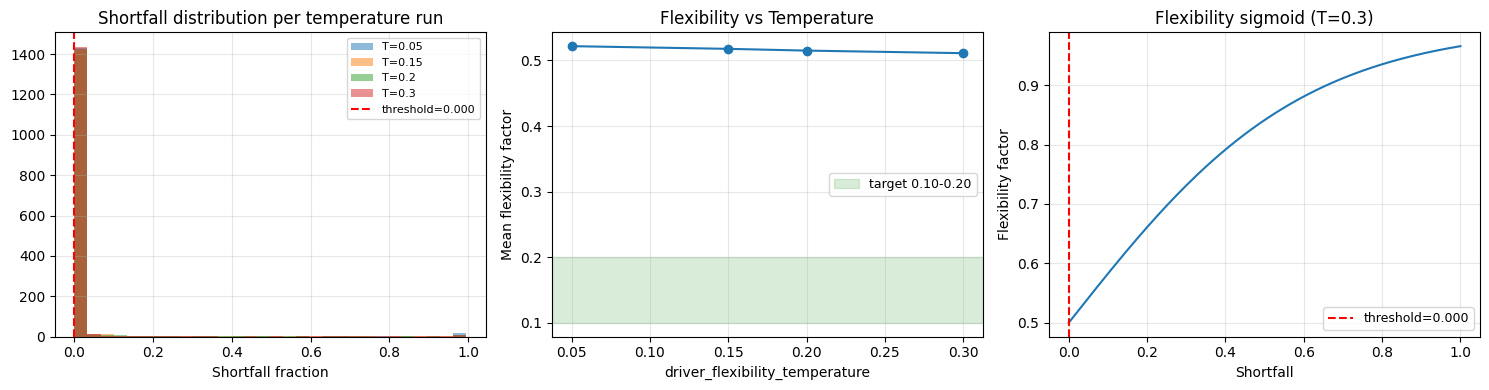

,temperature,p70,mean_flex
0,0.05,0.0,0.5218
1,0.15,0.0,0.5177
2,0.20,0.0,0.5151
3,0.30,0.0,0.5111


Layer 5 Recommendation
  driver_flexibility_threshold   = 0.000  (70th pct of shortfall at R=0.5)
  driver_flexibility_temperature = 0.3  (mean flexibility ≈ 0.51)

  Add to base config:
    "driver_flexibility_threshold": 0.000
    "driver_flexibility_temperature": 0.3

  CAL["driver_flexibility_threshold"] = 0.000
  CAL["driver_flexibility_temperature"] = 0.3


In [31]:
# Layer 5: analyze
RESULTS_L5 = Path(f'results/calibration/layer5_{GEOM_VARIANT}')

ptm5 = load_per_taxi_income(RESULTS_L5)
income_target = CAL.get('income_target_rate', 0.001)

if not ptm5:
    print('No shortfall data - run Layer 5 first.')
else:
    run_data = []
    for run_id, data in ptm5.items():
        m_T   = re.search(r'_ftemp_([\dp]+)', run_id)
        T     = float(m_T.group(1).replace('p', '.')) if m_T else None
        R_run = parse_run_id(run_id).get('R', L5_R)

        incomes  = [float(x) for x in data['income'] if x is not None]
        t_serve  = [float(x) for x in data['time_serving'] if x is not None]
        t_req    = [float(x) for x in data.get('time_to_request', [0]*len(incomes)) if x is not None]
        t_wait   = [float(x) for x in data.get('time_waiting', [0]*len(incomes)) if x is not None]
        t_cruise = [float(x) for x in data.get('time_cruising', [0]*len(incomes)) if x is not None]

        shortfalls = []
        for i in range(min(len(incomes), len(t_serve))):
            work = (t_serve[i]
                    + (t_req[i]    if i < len(t_req)    else 0)
                    + (t_wait[i]   if i < len(t_wait)   else 0)
                    + (t_cruise[i] if i < len(t_cruise) else 0))
            if work > 1:
                actual_rate = incomes[i] / work
                shortfall = max(0, income_target - actual_rate) / max(income_target, 1e-9)
                shortfalls.append(shortfall)

        if shortfalls:
            run_data.append({'run_id': run_id, 'temperature': T, 'R': R_run,
                             'shortfalls': shortfalls,
                             'p70': float(np.percentile(shortfalls, 70))})

    if not run_data:
        print('Could not compute shortfalls - check per-taxi metrics.')
    else:
        primary = [r for r in run_data if abs(r['R'] - L5_R)      < 0.01]
        stress  = [r for r in run_data if abs(r['R'] - L5_R_HIGH) < 0.01]

        rec_threshold = float(np.mean([r['p70'] for r in primary])) if primary else 0.0

        if rec_threshold == 0.0:
            print(f'  NOTE: driver_flexibility_threshold = 0.0 at R={L5_R}')
            print(f'  All 70th-pct drivers exceed income_target at this load level (expected).')
            if stress:
                print(f'  Using R={L5_R_HIGH} stress data for temperature calibration.')

        def mean_flex(shortfalls, threshold, T):
            return float(np.mean([1 / (1 + np.exp(-(s - threshold) / T)) for s in shortfalls]))

        temp_data = stress if (rec_threshold == 0.0 and stress) else primary
        R_label   = L5_R_HIGH if (stress and temp_data is stress) else L5_R

        rows5 = []
        for T_val in sorted(set(r['temperature'] for r in temp_data if r['temperature'] is not None)):
            runs_T = [r for r in temp_data if r['temperature'] == T_val]
            all_sf = [s for r in runs_T for s in r['shortfalls']]
            if all_sf:
                rows5.append({'temperature': T_val, 'R': R_label,
                              'p70': float(np.mean([r['p70'] for r in runs_T])),
                              'mean_flex': mean_flex(all_sf, rec_threshold, T_val)})
        df5r = pd.DataFrame(rows5).sort_values('temperature') if rows5 else pd.DataFrame()

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        for r in (stress if stress else primary):
            if r['temperature'] is not None:
                axes[0].hist(r['shortfalls'], bins=30, alpha=0.4, label=f'T={r["temperature"]}')
        axes[0].axvline(rec_threshold, color='red', linestyle='--',
                        label=f'threshold={rec_threshold:.3f}')
        axes[0].set_title(f'Shortfall distribution (R={R_label})')
        axes[0].set_xlabel('Shortfall fraction')
        axes[0].legend(fontsize=8)

        if not df5r.empty:
            axes[1].plot(df5r['temperature'], df5r['mean_flex'], 'o-', color='tab:blue')
            axes[1].axhspan(0.10, 0.20, alpha=0.15, color='green', label='target 0.10-0.20')
            axes[1].set_xlabel('driver_flexibility_temperature')
            axes[1].set_ylabel('Mean flexibility factor')
            axes[1].set_title(f'Flexibility vs Temperature (R={R_label})')
            axes[1].legend(fontsize=9)

        good = (df5r[(df5r['mean_flex'] >= 0.10) & (df5r['mean_flex'] <= 0.20)]
                if not df5r.empty else pd.DataFrame())
        if not good.empty:
            rec_T = float(good.iloc[len(good) // 2]['temperature'])
        elif not df5r.empty:
            rec_T = float(df5r.iloc[(df5r['mean_flex'] - 0.15).abs().argsort().iloc[0]]['temperature'])
        else:
            rec_T = 0.15

        xs = np.linspace(0, max(0.5, rec_threshold * 2 + 0.1), 200)
        ys = 1 / (1 + np.exp(-(xs - rec_threshold) / rec_T))
        axes[2].plot(xs, ys, 'tab:blue')
        axes[2].axvline(rec_threshold, color='red', linestyle='--',
                        label=f'threshold={rec_threshold:.3f}')
        axes[2].set_xlabel('Shortfall'); axes[2].set_ylabel('Flexibility factor')
        axes[2].set_title(f'Flexibility sigmoid (T={rec_T})')
        axes[2].legend(fontsize=9)
        plt.tight_layout(); plt.show()

        if not df5r.empty:
            display(df5r.reset_index(drop=True).round(4))

        print('Layer 5 Recommendation')
        print(f'  driver_flexibility_threshold   = {rec_threshold:.3f}  (70th pct shortfall at R={L5_R})')
        print(f'  driver_flexibility_temperature = {rec_T}  (calibrated from R={R_label})')
        if stress:
            stress_p70 = float(np.mean([r['p70'] for r in stress]))
            print(f'\n  Stress check at R={L5_R_HIGH}: p70 shortfall = {stress_p70:.3f}')
            if stress_p70 > 0.05:
                print('  -> flexibility mechanism activates under load; temperature well-calibrated.')
            else:
                print('  -> mechanism inactive even at stress R; consider higher L5_R_HIGH.')
        print()
        print('  Add to base config:')
        print(f'    "driver_flexibility_threshold": {rec_threshold:.3f}')
        print(f'    "driver_flexibility_temperature": {rec_T}')

        CAL['driver_flexibility_threshold'] = rec_threshold
        CAL['driver_flexibility_temperature'] = rec_T
        print(f'\n  CAL["driver_flexibility_threshold"] = {rec_threshold:.3f}')
        print(f'  CAL["driver_flexibility_temperature"] = {rec_T}')

---
## Layer 6 - Route-Length Preference Strength

Verifies that the preference strength parameters produce a statistically visible gap in accepted route lengths between short-pref and long-pref drivers. These are experimental design knobs set until the gap is clearly measurable.

> This layer applies to `nearest_distance_pref` only. For `nearest_region_pref`, Layer 7 covers the analogous calibration.

In [32]:
# Layer 6 params - edit these
L6_BASE   = CAL.get('base_config', BASE_CONF)
L6_D      = CAL.get('d', 258)
L6_R      = CAL.get('R', 0.5)
L6_GEOM   = GEOM
L6_BEHAV  = 1
L6_DAYS   = 1
L6_DIR    = f'configs/calibration/layer6_{GEOM_VARIANT}'

L6_PREF_HIGH_LIST   = [0.5, 0.7, 0.9]
L6_PREF_LOW         = 0.2
L6_NONPREF_CEILING  = 0.25
L6_BASE_ACCEPT_PROB = 0.90

In [33]:
# Layer 6: generate configs
gen6 = ConfigGenerator(L6_BASE, days=L6_DAYS)
configs6 = []
for high in L6_PREF_HIGH_LIST:
    conf = gen6.generate_config(L6_D, L6_R, 'nearest_distance_pref', L6_GEOM, L6_BEHAV,
                                no_breaks=False, constant_rate=False)
    if conf is None:
        continue
    conf['route_pref_strength_range'] = {'low': L6_PREF_LOW, 'high': high}
    conf['nonpreferred_accept_ceiling'] = L6_NONPREF_CEILING
    conf['preference_base_acceptance_prob'] = L6_BASE_ACCEPT_PROB
    if CAL.get('income_target_rate'):
        conf['income_target_rate'] = CAL['income_target_rate']
    if CAL.get('driver_flexibility_threshold'):
        conf['driver_flexibility_threshold'] = CAL['driver_flexibility_threshold']
        conf['driver_flexibility_temperature'] = CAL.get('driver_flexibility_temperature', 0.15)
    fname, content = gen6.dump_config(conf)
    high_tag = str(high).replace('.', 'p')
    fname = fname.replace('.conf', f'_prefhigh_{high_tag}.conf')
    conf_dict = json.loads(content)
    conf_dict['_prefhigh_tag'] = high
    configs6.append((fname, json.dumps(conf_dict, indent=4) + '\n'))

written6 = write_configs(configs6, L6_DIR)
print('Configs:', [p.name for p in written6])

Wrote 3 configs -> configs/calibration/layer6_balanced
Configs: ['big_city_base_balanced_days_1_d_258_R_0_50_alg_nearest_distance_pref_geom_10_behav_stay_ic_base_reset_false_prefhigh_0p5.conf', 'big_city_base_balanced_days_1_d_258_R_0_50_alg_nearest_distance_pref_geom_10_behav_stay_ic_base_reset_false_prefhigh_0p7.conf', 'big_city_base_balanced_days_1_d_258_R_0_50_alg_nearest_distance_pref_geom_10_behav_stay_ic_base_reset_false_prefhigh_0p9.conf']


In [34]:
# Layer 6: run
ok6, fail6 = run_batch_parallel(written6)

Running 3 configs with 13 parallel workers...
  [1/3] ok big_city_base_balanced_days_1_d_258_R_0_50_alg_nearest_distance_pref_geom_10_behav_stay_ic_base_reset_false_prefhigh_0p5.conf
  [2/3] ok big_city_base_balanced_days_1_d_258_R_0_50_alg_nearest_distance_pref_geom_10_behav_stay_ic_base_reset_false_prefhigh_0p9.conf
  [3/3] ok big_city_base_balanced_days_1_d_258_R_0_50_alg_nearest_distance_pref_geom_10_behav_stay_ic_base_reset_false_prefhigh_0p7.conf
Done - 3 OK, 0 failed


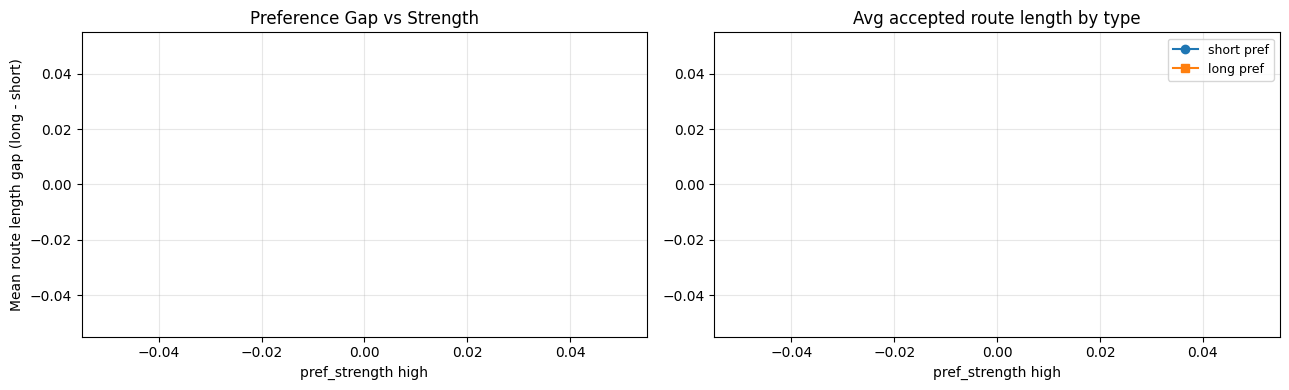

,pref_high,short_mean_len,long_mean_len,gap
0,0.5,None,None,None
1,0.7,None,None,None
2,0.9,None,None,None



Layer 6 Recommendation
  ? no gap data - check per-request metrics format
  nonpreferred_accept_ceiling     : 0.25
  preference_base_acceptance_prob : 0.9

  Add to base config:
    "route_pref_strength_range": {"low": 0.2, "high": 0.9}
    "nonpreferred_accept_ceiling": 0.25


In [35]:
# Layer 6: analyze
RESULTS_L6 = Path(f'results/calibration/layer6_{GEOM_VARIANT}')


def load_route_lengths_by_pref(results_dir):
    """Join per-request metrics with taxi_static to get driver route preference per trip.
    The route preference is a taxi attribute stored in taxi_static, not in per-request data."""
    out = {}
    result_path = Path(results_dir)
    for req_f in sorted(result_path.glob('run_*_per_request_metrics.json.gz')):
        run_id = re.sub(r'^run_', '', re.sub(r'_per_request_metrics\.json\.gz$', '', req_f.name))

        static_f = result_path / f'run_{run_id}_taxi_static.json.gz'
        taxi_pref = {}
        if static_f.exists():
            with gzip.open(static_f, 'rt') as fh:
                for line in fh:
                    if line.strip():
                        s = json.loads(line)
                        taxi_pref = dict(zip(s.get('taxi_ids', []),
                                            s.get('route_length_pref', [])))
                        break

        short_lens, long_lens, neutral_lens = [], [], []
        with gzip.open(req_f, 'rt') as fh:
            for line in fh:
                if line.strip():
                    for req in json.loads(line).get('requests', []):
                        if req.get('mode') != 'done':
                            continue
                        o = req.get('origin', [0, 0])
                        d = req.get('destination', [0, 0])
                        length = abs(o[0] - d[0]) + abs(o[1] - d[1])
                        if length == 0:
                            pu, do = req.get('pickup'), req.get('dropoff')
                            if pu is not None and do is not None:
                                length = abs(do - pu)
                        pref = taxi_pref.get(req.get('taxi_id'))
                        if pref == 'short_pref':
                            short_lens.append(float(length))
                        elif pref == 'long_pref':
                            long_lens.append(float(length))
                        elif pref == 'neutral_pref':
                            neutral_lens.append(float(length))
        out[run_id] = {'short': short_lens, 'long': long_lens, 'neutral': neutral_lens}
    return out


route_data6 = load_route_lengths_by_pref(RESULTS_L6)
df6 = load_aggregates(RESULTS_L6)

if not route_data6:
    print('No route data found - run Layer 6 first.')
else:
    rows6 = []
    for run_id, rd in route_data6.items():
        m = re.search(r'_prefhigh_([\dp]+)', run_id)
        high = float(m.group(1).replace('p', '.')) if m else None
        short_mean = np.mean(rd['short']) if rd['short'] else None
        long_mean  = np.mean(rd['long'])  if rd['long']  else None
        gap = (long_mean - short_mean) if (short_mean is not None and long_mean is not None) else None
        rows6.append({'run_id': run_id, 'pref_high': high,
                      'short_mean_len': short_mean, 'long_mean_len': long_mean,
                      'gap': gap,
                      'n_short': len(rd['short']), 'n_long': len(rd['long'])})
    df6r = pd.DataFrame(rows6).dropna(subset=['pref_high']).sort_values('pref_high')

    if not df6r.empty and 'gap' in df6r.columns:
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        axes[0].plot(df6r['pref_high'], df6r['gap'], 'o-', color='tab:blue')
        axes[0].set_xlabel('pref_strength high'); axes[0].set_ylabel('Mean route length gap (long - short)')
        axes[0].set_title('Preference Gap vs Strength')
        axes[1].plot(df6r['pref_high'], df6r['short_mean_len'], 'o-', label='short pref')
        axes[1].plot(df6r['pref_high'], df6r['long_mean_len'],  's-', label='long pref')
        axes[1].set_xlabel('pref_strength high')
        axes[1].set_title('Avg accepted route length by type')
        axes[1].legend(fontsize=9)
        plt.tight_layout(); plt.show()
        display(df6r[['pref_high', 'short_mean_len', 'long_mean_len', 'gap', 'n_short', 'n_long']].reset_index(drop=True).round(2))

    print('\nLayer 6 Recommendation')
    if not df6r.empty and df6r['gap'].notna().any():
        try:
            avg_req_len = base_for_l4.get('avg_request_lengths', 50)
        except NameError:
            avg_req_len = 50
        min_gap = avg_req_len * 0.3
        good6 = df6r[df6r['gap'] >= min_gap]
        if not good6.empty:
            rec_high = float(good6['pref_high'].min())
            gap_val  = float(good6[good6['pref_high'] == rec_high]['gap'].values[0])
            print(f'  ok  route_pref_strength_range: low={L6_PREF_LOW}, high={rec_high}')
            print(f'  Gap at this strength: {gap_val:.1f} units (target >= {min_gap:.1f})')
        else:
            rec_high = float(df6r['pref_high'].max())
            print(f'  ~ largest tested high ({rec_high}) gives gap {df6r["gap"].max():.1f};')
            print(f'    consider adding higher values to L6_PREF_HIGH_LIST')
    else:
        rec_high = L6_PREF_HIGH_LIST[-1]
        print(f'  ? no gap data - check taxi_static files exist in {RESULTS_L6}')

    print(f'  nonpreferred_accept_ceiling     : {L6_NONPREF_CEILING}')
    print(f'  preference_base_acceptance_prob : {L6_BASE_ACCEPT_PROB}')
    print()
    print('  Add to base config:')
    print(f'    "route_pref_strength_range": {{"low": {L6_PREF_LOW}, "high": {rec_high}}}')
    print(f'    "nonpreferred_accept_ceiling": {L6_NONPREF_CEILING}')

    CAL['route_pref_strength_high'] = rec_high
    CAL['route_pref_strength_low']  = L6_PREF_LOW

---
## Layer 7 - Region Preference *(optional)*

Applicable to `nearest_region_pref` and `nearest_two_sided_region_pass_pref`.  
Calibrates the `popularity` map so popular regions match the baseline service rate, unpopular regions drop 15–25 pp, and the overall drop stays below 10 pp.

In [39]:
# Layer 7 params - edit these
L7_BASE              = CAL.get('base_config', BASE_CONF)
L7_D                 = CAL.get('d', 258)
L7_R                 = CAL.get('R', 0.5)    # fixed from Layer 1 - do not change
L7_GEOM              = GEOM
L7_BEHAV             = 1
L7_DAYS              = 0.25
L7_DIR               = f'configs/calibration/layer7_{GEOM_VARIANT}'
L7_REGIONS_FILE      = 'regions_big_city_balanced.json'       # relative to configs/ - must exist

# Calibration target: how many declines a driver may make before forced acceptance
L7_MAX_DECLINES_LIST = [1, 2, 3, 5]

In [40]:
# Layer 7: generate configs (one baseline + one region_pref per max_declines value)
regions_path = Path('configs') / L7_REGIONS_FILE
if not regions_path.exists():
    print(f'Regions file not found: {regions_path}')
    print('Create it first, then re-run this cell.')
else:
    gen7 = ConfigGenerator(L7_BASE, days=L7_DAYS)
    configs7 = []

    # Single nearest baseline at calibrated R
    conf_base = gen7.generate_config(L7_D, L7_R, 'nearest', L7_GEOM, L7_BEHAV,
                                     no_breaks=True, constant_rate=True)
    if conf_base:
        fname, content = gen7.dump_config(conf_base)
        configs7.append((fname, content))

    # Region pref at each max_declines candidate
    for md in L7_MAX_DECLINES_LIST:
        conf_reg = gen7.generate_config(L7_D, L7_R, 'nearest_region_pref', L7_GEOM, L7_BEHAV,
                                        regions_file=L7_REGIONS_FILE,
                                        no_breaks=True, constant_rate=True)
        if conf_reg:
            conf_reg['max_declines'] = md
            fname, content = gen7.dump_config(conf_reg)
            fname = fname.replace('.conf', f'_md_{md}.conf')
            conf_dict = json.loads(content)
            conf_dict['_md_tag'] = md
            configs7.append((fname, json.dumps(conf_dict, indent=4) + '\n'))

    written7 = write_configs(configs7, L7_DIR)
    print('Configs:', [p.name for p in written7])

Wrote 5 configs -> configs/calibration/layer7_balanced
Configs: ['big_city_base_balanced_days_0_25_d_258_R_0_50_alg_nearest_geom_10_behav_stay_ic_base_reset_false.conf', 'big_city_base_balanced_days_0_25_d_258_R_0_50_alg_nearest_region_pref_geom_10_behav_stay_ic_base_reset_false_md_1.conf', 'big_city_base_balanced_days_0_25_d_258_R_0_50_alg_nearest_region_pref_geom_10_behav_stay_ic_base_reset_false_md_2.conf', 'big_city_base_balanced_days_0_25_d_258_R_0_50_alg_nearest_region_pref_geom_10_behav_stay_ic_base_reset_false_md_3.conf', 'big_city_base_balanced_days_0_25_d_258_R_0_50_alg_nearest_region_pref_geom_10_behav_stay_ic_base_reset_false_md_5.conf']


In [41]:
# Layer 7: run
ok7, fail7 = run_batch_parallel(written7)

Running 5 configs with 13 parallel workers...
  [1/5] ok big_city_base_balanced_days_0_25_d_258_R_0_50_alg_nearest_geom_10_behav_stay_ic_base_reset_false.conf
  [2/5] ok big_city_base_balanced_days_0_25_d_258_R_0_50_alg_nearest_region_pref_geom_10_behav_stay_ic_base_reset_false_md_2.conf
  [3/5] ok big_city_base_balanced_days_0_25_d_258_R_0_50_alg_nearest_region_pref_geom_10_behav_stay_ic_base_reset_false_md_5.conf
  [4/5] ok big_city_base_balanced_days_0_25_d_258_R_0_50_alg_nearest_region_pref_geom_10_behav_stay_ic_base_reset_false_md_1.conf
  [5/5] ok big_city_base_balanced_days_0_25_d_258_R_0_50_alg_nearest_region_pref_geom_10_behav_stay_ic_base_reset_false_md_3.conf
Done - 5 OK, 0 failed


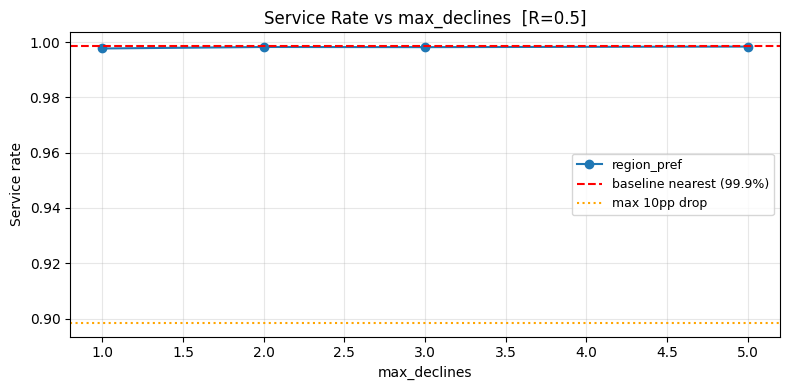

,max_declines,baseline_sr,region_sr,drop,ok
0,1,0.9985,0.9977,0.0008,True
1,2,0.9985,0.9982,0.0003,True
2,3,0.9985,0.9982,0.0004,True
3,5,0.9985,0.9984,0.0001,True



Layer 7 Recommendation  (baseline service rate: 99.9%)
  ok  max_declines = 1
    Service rate: 99.8%  (drop: 0.1%)

Per-region safety averages (first matching file):


,Unnamed: 0,timestamp,north_west_avg_safety_score,north_west_taxi_count,north_middle_avg_safety_score,north_middle_taxi_count,north_east_avg_safety_score,north_east_taxi_count,middle_west_avg_safety_score,middle_west_taxi_count,middle_middle_avg_safety_score,middle_middle_taxi_count,middle_east_avg_safety_score,middle_east_taxi_count,south_west_avg_safety_score,south_west_taxi_count,south_middle_avg_safety_score,south_middle_taxi_count,south_east_avg_safety_score,south_east_taxi_count
10,10,2013,56.3291,47,52.7240,59,53.5994,49,52.3114,51,57.6829,1087,54.0568,60,55.9946,29,55.4250,80,55.0002,40
11,11,2196,51.5432,37,51.8160,60,49.5663,49,54.7722,58,55.8452,1061,52.8570,78,47.9365,35,51.9496,76,52.0793,48
12,12,2379,54.3477,57,54.9058,137,53.7631,77,53.2794,148,52.7502,736,54.4741,107,50.3049,61,51.7621,116,50.8265,63



  CAL["max_declines"] = 1


In [42]:
# Layer 7: analyze
RESULTS_L7 = Path(f'results/calibration/layer7_{GEOM_VARIANT}')

df7  = load_aggregates(RESULTS_L7)
svc7 = load_service_stats(RESULTS_L7)

if df7.empty:
    print('No results - run Layer 7 first.')
else:
    df7['service_rate'] = df7['run_id'].map({k: v['service_rate'] for k, v in svc7.items()})
    df7['is_region']    = df7['matching'].str.contains('region', na=False)
    df7['max_declines'] = df7['run_id'].str.extract(r'_md_(\d+)')[0].astype(float)

    base_sr = df7[~df7['is_region']]['service_rate'].mean()

    rows7 = []
    for md_val in sorted(df7['max_declines'].dropna().unique()):
        sub = df7[(df7['is_region']) & (df7['max_declines'] == md_val)]
        reg_sr = sub['service_rate'].mean()
        if pd.notna(base_sr) and pd.notna(reg_sr):
            drop = base_sr - reg_sr
            rows7.append({'max_declines': int(md_val), 'baseline_sr': base_sr,
                          'region_sr': reg_sr, 'drop': drop, 'ok': drop <= 0.10})

    df7r = pd.DataFrame(rows7)

    if not df7r.empty:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(df7r['max_declines'], df7r['region_sr'], 'o-', color='tab:blue', label='region_pref')
        ax.axhline(base_sr, color='red', linestyle='--', label=f'baseline nearest ({base_sr:.1%})')
        ax.axhline(base_sr - 0.10, color='orange', linestyle=':', label='max 10pp drop')
        ax.set_xlabel('max_declines'); ax.set_ylabel('Service rate')
        ax.set_title(f'Service Rate vs max_declines  [R={L7_R}]')
        ax.legend(fontsize=9)
        plt.tight_layout(); plt.show()
        display(df7r.round(4))

    print(f'\nLayer 7 Recommendation  (baseline service rate: {base_sr:.1%})')
    good7 = df7r[df7r['ok']] if not df7r.empty else pd.DataFrame()
    if not good7.empty:
        rec_md = int(good7['max_declines'].min())
        row = good7[good7['max_declines'] == rec_md].iloc[0]
        print(f'  ok  max_declines = {rec_md}')
        print(f'    Service rate: {row["region_sr"]:.1%}  (drop: {row["drop"]:.1%})')
    else:
        rec_md = int(df7r['max_declines'].max()) if not df7r.empty else L7_MAX_DECLINES_LIST[-1]
        print(f'  ~ no value keeps drop <= 10pp; best is {rec_md}')
        print('    Consider adjusting popularity weights in regions.json')

    reg_files = list(RESULTS_L7.glob('run_*nearest_region*_region_safety_averages.csv.gz'))
    if reg_files:
        print('\nPer-region safety averages (first matching file):')
        rdf = pd.read_csv(reg_files[0])
        display(rdf.tail(3))

    CAL['max_declines'] = rec_md
    print(f'\n  CAL["max_declines"] = {rec_md}')

---
## Layer 8 - Passenger Preferences

Passenger parameters interact with the matching algorithm and the safety score distribution from Layer 3. The `safety_strict` passenger type rejects a measurably higher fraction of drivers than `safety_indifferent` across a range of safety score distributions. Sweeps `passenger_score_temperature` and safety thresholds; compares acceptance rates by passenger type.

In [43]:
# Layer 8 params - edit these
L8_BASE  = CAL.get('base_config', BASE_CONF)
L8_D     = CAL.get('d', 258)
L8_R     = CAL.get('R', 0.5)
L8_GEOM  = GEOM
L8_BEHAV = 1
L8_DAYS  = 1
L8_DIR   = f'configs/calibration/layer8_{GEOM_VARIANT}'

L8_TEMPERATURES = [0.05, 0.10, 0.20, 0.40]
L8_ALGORITHMS   = ['nearest', 'nearest_passenger_pref']

# Derive safety thresholds from the actual 1-day safety equilibrium distribution.
# Hardcoded values (e.g. strict=75) cause >50% rejection because safety scores
# degrade during a full day. Target: strict rejects ~20-25%, moderate ~10-15%.
_prev_results = Path(f'results/calibration/layer8_{GEOM_VARIANT}')
_safety_sample = []
for _f in sorted(_prev_results.glob('run_*_per_taxi_metrics.json.gz')):
    with gzip.open(_f, 'rt') as _fh:
        _lines = [_l for _l in _fh if _l.strip()]
    if _lines:
        _last = json.loads(_lines[-1])
        _safety_sample.extend([float(_s) for _s in _last.get('safety_score', []) if _s is not None])
    if len(_safety_sample) >= 200:
        break

if not _safety_sample:
    _safety3 = load_safety_scores(Path(f'results/calibration/layer3_{GEOM_VARIANT}'))
    for _sc in _safety3.values():
        _safety_sample.extend(_sc.get('final', []))

if _safety_sample:
    _p10 = float(np.percentile(_safety_sample, 10))
    _p25 = float(np.percentile(_safety_sample, 25))
    _std = float(np.std(_safety_sample))
    _src_label = 'Layer 8 equilibrium' if (
        _prev_results.exists() and any(_prev_results.glob('*.gz'))
    ) else 'Layer 3 proxy (re-run Layer 8 after first run to update)'
    print(f'Safety distribution ({_src_label}):')
    print(f'  mean={np.mean(_safety_sample):.1f}  p10={_p10:.1f}  p25={_p25:.1f}  std={_std:.1f}')
    L8_SAFETY_THRESHOLDS = {
        'safety_indifferent': {'mean': 0.0,            'std': 0.0},
        'safety_moderate':    {'mean': round(_p10, 1), 'std': round(_std * 0.3, 1)},
        'safety_strict':      {'mean': round(_p25, 1), 'std': round(_std * 0.3, 1)},
    }
    print(f'  -> moderate threshold: {L8_SAFETY_THRESHOLDS["safety_moderate"]["mean"]}  (~10% rejected)')
    print(f'  -> strict  threshold: {L8_SAFETY_THRESHOLDS["safety_strict"]["mean"]}  (~25% rejected)')
else:
    print('WARNING: no safety data; using conservative fallback thresholds.')
    L8_SAFETY_THRESHOLDS = {
        'safety_indifferent': {'mean': 0.0,  'std': 0.0},
        'safety_moderate':    {'mean': 55.0, 'std': 8.0},
        'safety_strict':      {'mean': 65.0, 'std': 6.0},
    }

In [44]:
# Layer 8: generate configs
gen8 = ConfigGenerator(L8_BASE, days=L8_DAYS)
configs8 = []
for alg in L8_ALGORITHMS:
    for T in L8_TEMPERATURES:
        conf = gen8.generate_config(L8_D, L8_R, alg, L8_GEOM, L8_BEHAV,
                                    no_breaks=False, constant_rate=False)
        if conf is None:
            continue
        conf['passenger_score_temperature']  = T
        conf['passenger_safety_threshold']   = L8_SAFETY_THRESHOLDS
        for key in ['income_target_rate', 'satisfaction_income_ref',
                    'satisfaction_change_waiting_rate', 'safety_score_change_serving_rate',
                    'safety_score_break_recovery_constant', 'driver_flexibility_threshold',
                    'driver_flexibility_temperature']:
            if key in CAL and CAL[key] is not None:
                conf[key] = CAL[key]
        T_tag = str(T).replace('.', 'p')
        fname, content = gen8.dump_config(conf)
        fname = fname.replace('.conf', f'_ptemp_{T_tag}.conf')
        conf_dict = json.loads(content)
        conf_dict['_ptemp_tag'] = T
        configs8.append((fname, json.dumps(conf_dict, indent=4) + '\n'))

written8 = write_configs(configs8, L8_DIR)
print('Configs:', [p.name for p in written8])

Wrote 8 configs -> configs/calibration/layer8_balanced
Configs: ['big_city_base_balanced_days_1_d_258_R_0_50_alg_nearest_geom_10_behav_stay_ic_base_reset_false_ptemp_0p05.conf', 'big_city_base_balanced_days_1_d_258_R_0_50_alg_nearest_geom_10_behav_stay_ic_base_reset_false_ptemp_0p1.conf', 'big_city_base_balanced_days_1_d_258_R_0_50_alg_nearest_geom_10_behav_stay_ic_base_reset_false_ptemp_0p2.conf', 'big_city_base_balanced_days_1_d_258_R_0_50_alg_nearest_geom_10_behav_stay_ic_base_reset_false_ptemp_0p4.conf', 'big_city_base_balanced_days_1_d_258_R_0_50_alg_nearest_passenger_pref_geom_10_behav_stay_ic_base_reset_false_ptemp_0p05.conf', 'big_city_base_balanced_days_1_d_258_R_0_50_alg_nearest_passenger_pref_geom_10_behav_stay_ic_base_reset_false_ptemp_0p1.conf', 'big_city_base_balanced_days_1_d_258_R_0_50_alg_nearest_passenger_pref_geom_10_behav_stay_ic_base_reset_false_ptemp_0p2.conf', 'big_city_base_balanced_days_1_d_258_R_0_50_alg_nearest_passenger_pref_geom_10_behav_stay_ic_base_reset_

In [47]:
# Layer 8: run
ok8, fail8 = run_batch_parallel(written8)

Running 8 configs with 13 parallel workers...
  [1/8] ok big_city_base_balanced_days_1_d_258_R_0_50_alg_nearest_geom_10_behav_stay_ic_base_reset_false_ptemp_0p2.conf
  [2/8] ok big_city_base_balanced_days_1_d_258_R_0_50_alg_nearest_geom_10_behav_stay_ic_base_reset_false_ptemp_0p05.conf
  [3/8] ok big_city_base_balanced_days_1_d_258_R_0_50_alg_nearest_geom_10_behav_stay_ic_base_reset_false_ptemp_0p4.conf
  [4/8] ok big_city_base_balanced_days_1_d_258_R_0_50_alg_nearest_geom_10_behav_stay_ic_base_reset_false_ptemp_0p1.conf
  [5/8] ok big_city_base_balanced_days_1_d_258_R_0_50_alg_nearest_passenger_pref_geom_10_behav_stay_ic_base_reset_false_ptemp_0p4.conf
  [6/8] ok big_city_base_balanced_days_1_d_258_R_0_50_alg_nearest_passenger_pref_geom_10_behav_stay_ic_base_reset_false_ptemp_0p2.conf
  [7/8] ok big_city_base_balanced_days_1_d_258_R_0_50_alg_nearest_passenger_pref_geom_10_behav_stay_ic_base_reset_false_ptemp_0p1.conf
  [8/8] ok big_city_base_balanced_days_1_d_258_R_0_50_alg_nearest_pa

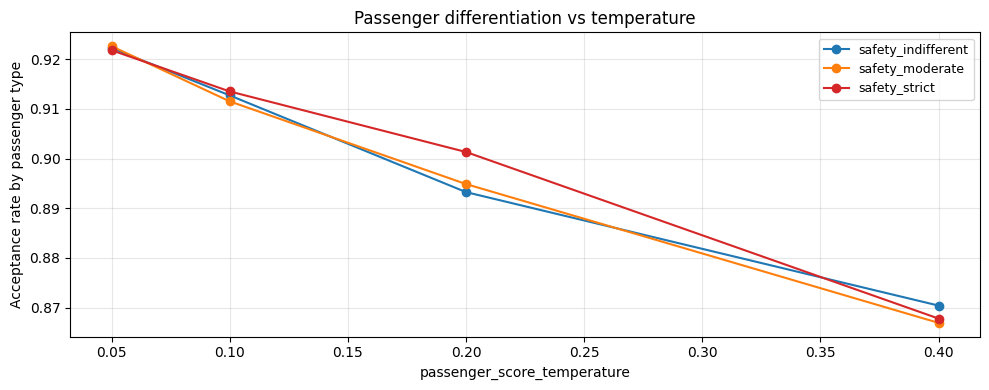

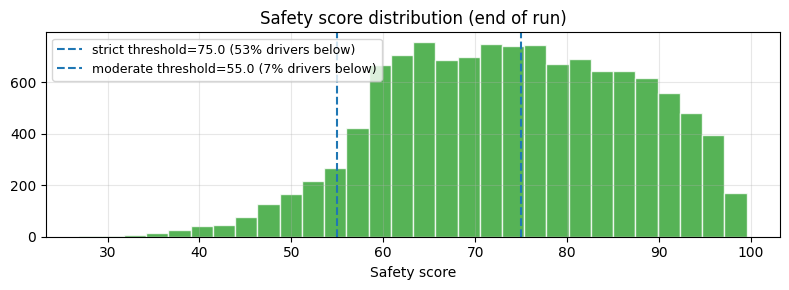


Layer 8 Recommendation
  ~ gap < 0.15 for all tested temperatures
    consider lowering strict threshold (75.0) or raising initial_safety_score_max

  53% of drivers end below strict threshold (75.0)
  -> too many rejections: raise threshold or adjust safety dynamics (Layer 3)

  Add to base config:
    "passenger_score_temperature": 0.1
    "passenger_safety_threshold": (from L8_SAFETY_THRESHOLDS above)

  CAL["passenger_score_temperature"] = 0.1


In [48]:
# Layer 8: analyze
RESULTS_L8 = Path(f'results/calibration/layer8_{GEOM_VARIANT}')

def load_passenger_acceptance(results_dir):
    out = {}
    for f in sorted(Path(results_dir).glob('run_*_per_request_metrics.json.gz')):
        run_id = re.sub(r'^run_', '', re.sub(r'_per_request_metrics\.json\.gz$', '', f.name))
        accepted = {}
        rejected = {}
        with gzip.open(f, 'rt') as fh:
            for line in fh:
                if line.strip():
                    for req in json.loads(line).get('requests', []):
                        ptype = req.get('passenger_type', 'unknown')
                        if req.get('mode') == 'done':
                            accepted[ptype] = accepted.get(ptype, 0) + 1
                        elif req.get('mode') == 'dropped':
                            reason = req.get('cancellation_reason', '')
                            if 'passenger' in str(reason).lower() or 'pref' in str(reason).lower():
                                rejected[ptype] = rejected.get(ptype, 0) + 1
        if accepted or rejected:
            all_types = set(list(accepted.keys()) + list(rejected.keys()))
            rate = {}
            for pt in all_types:
                a = accepted.get(pt, 0); r = rejected.get(pt, 0)
                rate[pt] = a / (a + r) if (a + r) > 0 else None
            out[run_id] = rate
    return out

pax8    = load_passenger_acceptance(RESULTS_L8)
svc8    = load_service_stats(RESULTS_L8)
df8     = load_aggregates(RESULTS_L8)
safety8 = load_safety_scores(RESULTS_L8)

if df8.empty:
    print('No results - run Layer 8 first.')
else:
    df8['service_rate'] = df8['run_id'].map({k: v['service_rate'] for k, v in svc8.items()})
    df8 = add_utilization(df8)

    m = df8['run_id'].str.extract(r'_ptemp_([\dp]+)')
    df8['temperature'] = m[0].str.replace('p', '.').astype(float)

    rows8 = []
    for run_id, rates in pax8.items():
        m2 = re.search(r'_ptemp_([\dp]+)', run_id)
        T  = float(m2.group(1).replace('p', '.')) if m2 else None
        alg = parse_run_id(run_id).get('matching', '?')
        rows8.append({'run_id': run_id, 'temperature': T, 'matching': alg, **rates})
    df8r = pd.DataFrame(rows8)

    pax_types = [c for c in ['safety_indifferent','safety_moderate','safety_strict'] if c in df8r.columns]

    if pax_types and not df8r.empty:
        pref_df = df8r[df8r['matching'].str.contains('pref', na=False)]
        if not pref_df.empty:
            fig, ax = plt.subplots(figsize=(10, 4))
            temps = sorted(pref_df['temperature'].dropna().unique())
            colors = ['tab:blue', 'tab:orange', 'tab:red']
            for pt, col in zip(pax_types, colors):
                vals = [pref_df[pref_df['temperature']==T][pt].mean() for T in temps]
                ax.plot(temps, vals, 'o-', label=pt, color=col)
            ax.set_xlabel('passenger_score_temperature')
            ax.set_ylabel('Acceptance rate by passenger type')
            ax.set_title('Passenger differentiation vs temperature')
            ax.legend(fontsize=9)
            plt.tight_layout(); plt.show()

    safety_vals = []
    for rid, sc in safety8.items():
        safety_vals.extend(sc.get('final', []))
    if safety_vals:
        fig2, ax2 = plt.subplots(figsize=(8, 3))
        ax2.hist(safety_vals, bins=30, color='tab:green', edgecolor='white', alpha=0.8)
        for pt, threshold in [('strict', L8_SAFETY_THRESHOLDS.get('safety_strict',{}).get('mean',75)),
                               ('moderate', L8_SAFETY_THRESHOLDS.get('safety_moderate',{}).get('mean',55))]:
            frac_below = np.mean([s < threshold for s in safety_vals])
            ax2.axvline(threshold, linestyle='--',
                        label=f'{pt} threshold={threshold} ({frac_below:.0%} drivers below)')
        ax2.set_xlabel('Safety score'); ax2.set_title('Safety score distribution (end of run)')
        ax2.legend(fontsize=9)
        plt.tight_layout(); plt.show()

    print('\nLayer 8 Recommendation')
    if not df8r.empty and pax_types and len(pax_types) >= 2:
        pref_df = df8r[df8r['matching'].str.contains('pref', na=False)].copy()
        if 'safety_indifferent' in pref_df.columns and 'safety_strict' in pref_df.columns:
            pref_df['gap'] = pref_df['safety_indifferent'] - pref_df['safety_strict']
            by_temp = pref_df.groupby('temperature')['gap'].mean()
            good8 = by_temp[by_temp > 0.15]
            if not good8.empty:
                rec_T = float(good8.index.max())
                print(f'  passenger_score_temperature = {rec_T}')
                print(f'  Indifferent-strict gap at this T: {good8[rec_T]:.2f}')
            else:
                rec_T = float(L8_TEMPERATURES[1])
                print(f'  ~ gap < 0.15 for all tested temperatures')
                print(f'    consider lowering strict threshold ({L8_SAFETY_THRESHOLDS["safety_strict"]["mean"]}) or raising initial_safety_score_max')
        else:
            rec_T = 0.10
            print(f'  ? passenger type data sparse - defaulting to T={rec_T}')
    else:
        rec_T = 0.10
        print(f'  ? no passenger-type acceptance data found in per-request metrics')

    if safety_vals:
        strict_thresh = L8_SAFETY_THRESHOLDS.get('safety_strict', {}).get('mean', 75)
        frac_rejected = np.mean([s < strict_thresh for s in safety_vals])
        print(f'\n  {frac_rejected:.0%} of drivers end below strict threshold ({strict_thresh})')
        if frac_rejected < 0.05:
            print('  -> too few rejections: lower strict threshold or decrease safety_score_min')
        elif frac_rejected > 0.50:
            print('  -> too many rejections: raise threshold or adjust safety dynamics (Layer 3)')
        else:
            print('  -> fraction in good range (5-50%)')

    print()
    print('  Add to base config:')
    print(f'    "passenger_score_temperature": {rec_T}')
    print(f'    "passenger_safety_threshold": (from L8_SAFETY_THRESHOLDS above)')

    CAL['passenger_score_temperature'] = rec_T
    print(f'\n  CAL["passenger_score_temperature"] = {rec_T}')

---
## Final Summary - All Calibrated Values

In [49]:
# Summary of all calibrated values
print('-' * 50)
print('  CALIBRATION SUMMARY')
print('-' * 50)
layers = [
    ('Layer 1',  ['R', 'd']),
    ('Layer 2',  ['income_target_rate', 'mean_income_rate', 'median_trip_income']),
    ('Layer 3',  ['safety_score_change_serving_rate', 'safety_score_break_recovery_constant']),
    ('Layer 4',  ['satisfaction_income_ref', 'satisfaction_change_waiting_rate']),
    ('Layer 5',  ['driver_flexibility_threshold', 'driver_flexibility_temperature']),
    ('Layer 6',  ['route_pref_strength_low', 'route_pref_strength_high']),
    ('Layer 8',  ['passenger_score_temperature']),
]
for layer, keys in layers:
    print(f'\n  {layer}')
    for k in keys:
        v = CAL.get(k)
        if v is not None:
            print(f'    {k:<45s} = {v}')
        else:
            print(f'    {k:<45s}   (not set - run that layer)')
print()
print('-' * 50)

--------------------------------------------------
  CALIBRATION SUMMARY
--------------------------------------------------

  Layer 1
    R                                             = 0.5
    d                                             = 258

  Layer 2
    income_target_rate                            = 0.418054
    mean_income_rate                              = 0.4918287564996041
    median_trip_income                            = 1275.9679999999998

  Layer 3
    safety_score_change_serving_rate              = -0.025
    safety_score_break_recovery_constant          = 180.0

  Layer 4
    satisfaction_income_ref                       = 1375.7
    satisfaction_change_waiting_rate              = -0.003

  Layer 5
    driver_flexibility_threshold                  = 0.0
    driver_flexibility_temperature                = 0.3

  Layer 6
    route_pref_strength_low                       = 0.2
    route_pref_strength_high                      = 0.9

  Layer 8
    passenger_score_tempe

In [50]:
# Write calibrated values to a patch file
EXPORT_PATH = Path('configs/calibration_patch.json')

EXPORTABLE = [
    'income_target_rate',
    'safety_score_change_serving_rate',
    'safety_score_break_recovery_constant',
    'satisfaction_income_ref',
    'satisfaction_change_waiting_rate',
    'driver_flexibility_threshold',
    'driver_flexibility_temperature',
    'passenger_score_temperature',
]
patch = {k: CAL[k] for k in EXPORTABLE if k in CAL and CAL[k] is not None}

if 'route_pref_strength_low' in CAL and 'route_pref_strength_high' in CAL:
    patch['route_pref_strength_range'] = {
        'low':  CAL['route_pref_strength_low'],
        'high': CAL['route_pref_strength_high'],
    }

EXPORT_PATH.write_text(json.dumps(patch, indent=4) + '\n')
print(f'Patch written to {EXPORT_PATH}:')
print(json.dumps(patch, indent=4))

Patch written to configs\calibration_patch.json:
{
    "income_target_rate": 0.418054,
    "safety_score_change_serving_rate": -0.025,
    "safety_score_break_recovery_constant": 180.0,
    "satisfaction_income_ref": 1375.7,
    "satisfaction_change_waiting_rate": -0.003,
    "driver_flexibility_threshold": 0.0,
    "driver_flexibility_temperature": 0.3,
    "passenger_score_temperature": 0.1,
    "route_pref_strength_range": {
        "low": 0.2,
        "high": 0.9
    }
}
